# Student Academic Performance Prediction For Resource Planning


In [1]:
#import  libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
#dataset upload
from google.colab import files
upload = files.upload()


Saving student-mat.csv to student-mat (3).csv


In [3]:
#reading csv file into a dataframe
df =pd.read_csv('student-mat.csv', sep=';')
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [4]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.shape

(395, 33)

In [7]:
#column names
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [17]:
df.isna().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [18]:
df.duplicated().sum()

np.int64(0)

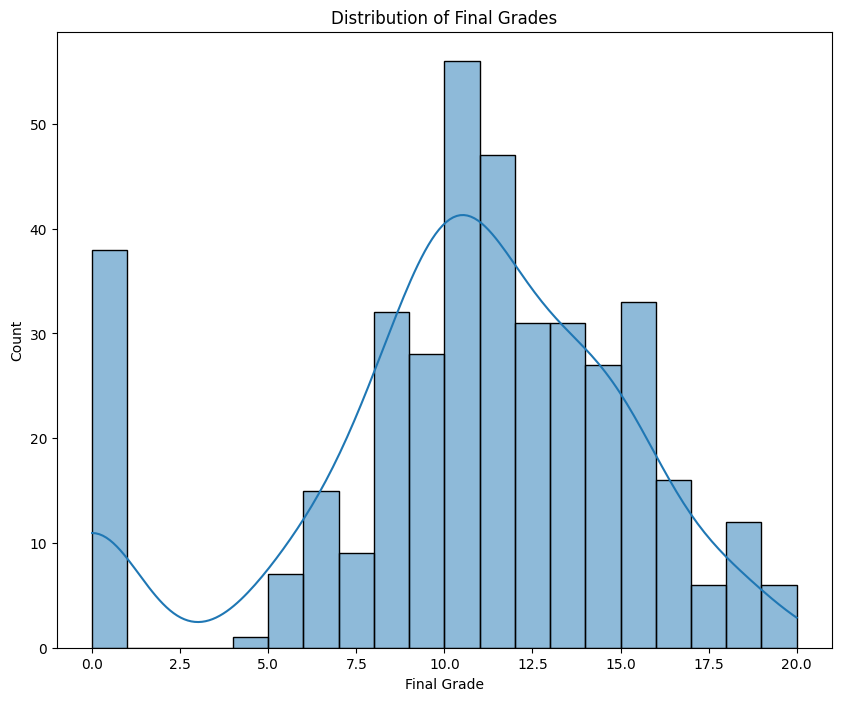

In [19]:
# Distribution of final grades (G3)
plt.figure(figsize=(10,8))
sns.histplot(df['G3'], bins=20, kde=True)
plt.xlabel('Final Grade')
plt.ylabel('Count')
plt.title('Distribution of Final Grades')
plt.show()

In [20]:
# G3 =0 records
zero_final_math = df[df['G3']==0]
print(zero_final_math.head(10))
print(zero_final_math.shape)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
128     GP   M   18       R     GT3       T     2     2  services     other   
130     GP   F   15       R     GT3       T     3     4  services   teacher   
131     GP   F   15       U     GT3       T     1     1   at_home     other   
134     GP   M   15       R     GT3       T     3     4   at_home   teacher   
135     GP   F   15       U     GT3       T     4     4  services   at_home   
136     GP   M   17       R     GT3       T     3     4   at_home     other   
137     GP   F   16       U     GT3       A     3     3     other     other   
140     GP   M   15       U     GT3       T     4     3   teacher  services   
144     GP   M   17       U     GT3       T     2     1     other     other   
146     GP   F   15       U     GT3       T     3     2    health  services   

         reason guardian  traveltime  studytime  failures schoolsup famsup  \
128  reputation   mother           1          1     

In [21]:
zero_final_math.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [22]:
#health column caries values [1,2,3,4,5]
print(df['health'].value_counts())
print(df['health'].describe())
print(df['health'].info())


health
5    146
3     91
4     66
1     47
2     45
Name: count, dtype: int64
count    395.000000
mean       3.554430
std        1.390303
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        5.000000
Name: health, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 395 entries, 0 to 394
Series name: health
Non-Null Count  Dtype
--------------  -----
395 non-null    int64
dtypes: int64(1)
memory usage: 3.2 KB
None


In [23]:
display(zero_final_math[['G1', 'G2', 'absences', 'failures', 'health','studytime']])

,G1,G2,absences,failures,health,studytime
128,7,4,0,2,4,1
130,12,0,0,2,5,3
131,8,0,0,0,4,1
134,9,0,0,0,5,2
135,11,0,0,0,5,3
136,10,0,0,0,5,2
137,4,0,0,2,5,1
140,7,9,0,0,3,4
144,5,0,0,3,5,1
146,6,7,0,3,3,2


In [24]:
zero_final_math[['G1', 'G2', 'G3','absences']].describe()
#There are no absences

,G1,G2,G3,absences
count,38.000000,38.000000,38.0,38.0
mean,7.526316,4.657895,0.0,0.0
std,1.811925,3.700083,0.0,0.0
min,4.000000,0.000000,0.0,0.0
25%,6.000000,0.000000,0.0,0.0
50%,7.000000,5.000000,0.0,0.0
75%,9.000000,8.000000,0.0,0.0
max,12.000000,10.000000,0.0,0.0


In [25]:
# G3<10 is set as thrshold for academic risk
df['academic_risk']=(df['G3']<10).astype(int)

In [26]:
risk_counts =df['academic_risk'].value_counts().sort_index()
print(risk_counts)

academic_risk
0    265
1    130
Name: count, dtype: int64


In [27]:
risk_percentages=(df['academic_risk']).value_counts(normalize=True).sort_index()*100
print(risk_percentages)

academic_risk
0    67.088608
1    32.911392
Name: proportion, dtype: float64


In [28]:
130/395

0.3291139240506329

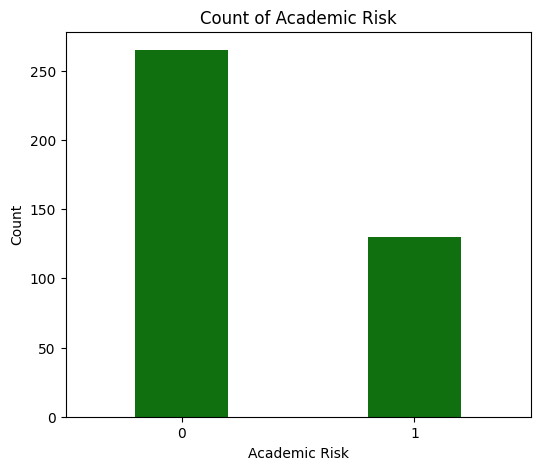

In [29]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='academic_risk', width=0.4, color='green')
plt.xlabel('Academic Risk')
plt.ylabel('Count')
plt.title('Count of Academic Risk')
plt.show()

In [30]:
len(df)

395

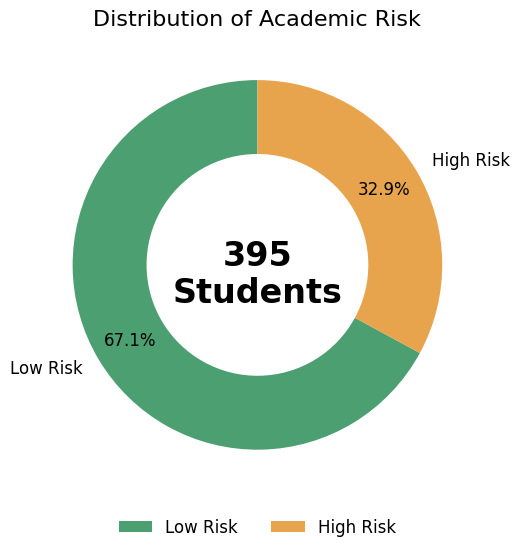

In [31]:
labels_risk = ['Low Risk', 'High Risk']
plt.figure(figsize =(6,6))
wedges, texts, autotexts=plt.pie(risk_counts, labels=labels_risk,
        autopct='%1.1f%%',startangle=90, colors=['#4C9F70', '#E8A44D'],
        wedgeprops={'width': 0.4}, pctdistance=0.8,
       labeldistance=1.1,textprops={'fontsize':12})
plt.text(0, 0.05,
         str(len(df)),
         ha='center',
         va='center',
         fontsize=24,
         fontweight='bold')
plt.text(0, -0.15,
         'Students',
         ha='center',
         va='center',
         fontsize=24,
         fontweight='bold')
plt.legend(wedges,labels_risk,loc ='lower center',
           bbox_to_anchor=(0.5, -0.12),
           ncol=2, fontsize=12, frameon=False)
plt.title('Distribution of Academic Risk', fontsize=16)
plt.show()


In [32]:
# study time analysis
studytime_summary = (df.groupby('studytime')['G3'].agg(['count', 'mean', 'median', 'std']).round(2))
display(studytime_summary)

,count,mean,median,std
studytime,,,,
1,105,10.05,10.0,4.96
2,198,10.17,11.0,4.22
3,65,11.40,12.0,4.64
4,27,11.26,12.0,5.28


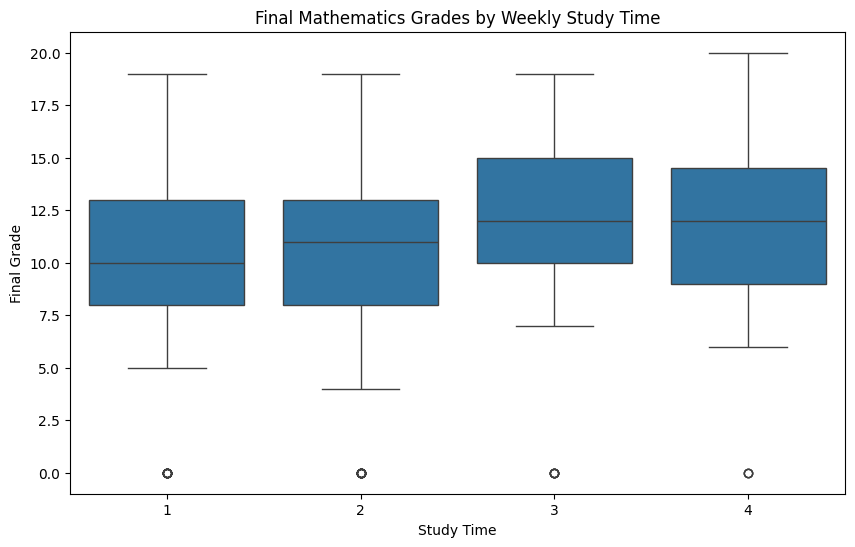

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data =df,
            x= 'studytime',
            y='G3')
plt.xlabel('Study Time')
plt.ylabel('Final Grade')
plt.title('Final Mathematics Grades by Weekly Study Time')
plt.show()

In [34]:
#failures analysis
#failures column has values [0, 1, 2, 3]
failures_summary=(df.groupby('failures')['G3'].agg(['count', 'mean', 'median', 'std']).round(2))
#print(failures_summary.to_markdown())
display(failures_summary)

,count,mean,median,std
failures,,,,
0,312,11.25,11.0,4.17
1,50,8.12,9.0,4.71
2,17,6.24,8.0,4.84
3,16,5.69,7.0,4.19


In [35]:
df['failures'].value_counts()

,count
failures,
0,312
1,50
2,17
3,16


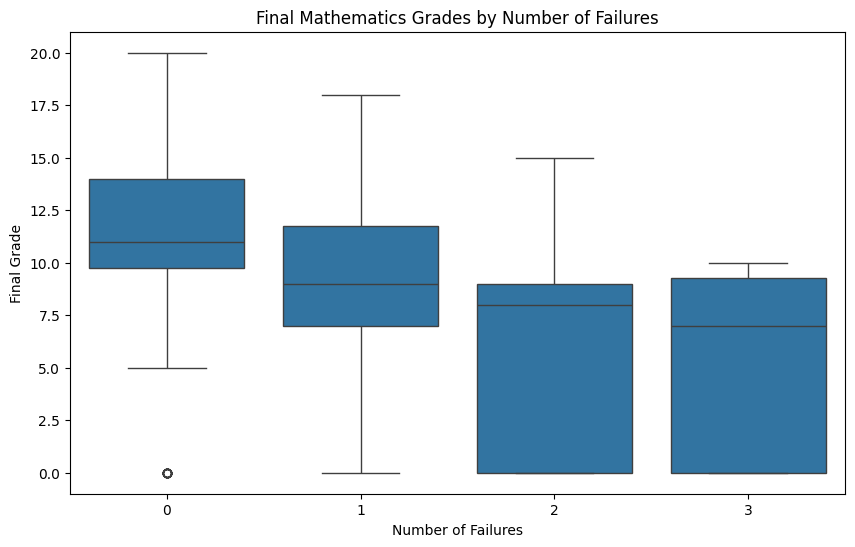

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data =df,
            x= 'failures',
            y='G3')
plt.xlabel('Number of Failures')
plt.ylabel('Final Grade')
plt.title('Final Mathematics Grades by Number of Failures')
plt.show()
#

In [37]:
studytime_summary_G3zero = (zero_final_math.groupby('studytime')['G3'].agg(['count', 'mean', 'median', 'std']).round(2))
display(studytime_summary_G3zero)

,count,mean,median,std
studytime,,,,
1,13,0.0,0.0,0.0
2,16,0.0,0.0,0.0
3,6,0.0,0.0,0.0
4,3,0.0,0.0,0.0


In [38]:
Health_summary=(zero_final_math.groupby('health')[['G1', 'G2', 'G3']].agg(['count', 'mean', 'median', 'std']).round(2))
display(Health_summary)

G1                       G2                       G3              \
       count  mean median   std count  mean median   std count mean median   
health                                                                       
1          2  7.50    7.5  0.71     2  7.00    7.0  1.41     2  0.0    0.0   
2          7  8.29    8.0  1.70     7  8.00    8.0  1.63     7  0.0    0.0   
3          8  7.25    7.0  1.28     8  5.25    7.0  4.46     8  0.0    0.0   
4          8  7.25    7.0  1.67     8  4.12    4.5  3.76     8  0.0    0.0   
5         13  7.46    7.0  2.37    13  2.46    0.0  2.79    13  0.0    0.0   

             
        std  
health       
1       0.0  
2       0.0  
3       0.0  
4       0.0  
5       0.0

In [39]:
study_zero_pct=(
    df.groupby('studytime')['G3']
    .apply(lambda x: (x==0).mean()*100).round(2)
)
display(study_zero_pct)


,G3
studytime,
1,12.38
2,8.08
3,9.23
4,11.11


In [40]:
df['studytime'].value_counts()

,count
studytime,
2,198
1,105
3,65
4,27


In [41]:
zero_final_math['studytime'].value_counts()

,count
studytime,
2,16
1,13
3,6
4,3


In [42]:
study_risk_pct = (
    df.groupby('studytime')['academic_risk']
    .mean()
    .mul(100)
    .round(2)
)
display(study_risk_pct)


,academic_risk
studytime,
1,35.24
2,35.35
3,24.62
4,25.93


In [43]:
grade_corr = df[['G1', 'G2', 'G3']].corr()
display(grade_corr)
#print(grade_corr.to_markdown())

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


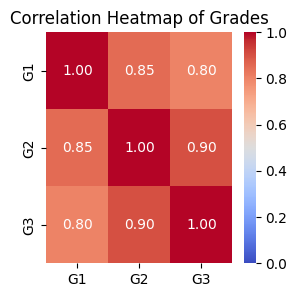

In [44]:
plt.figure(figsize=(3, 3))
sns.heatmap(grade_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title('Correlation Heatmap of Grades')
plt.show()

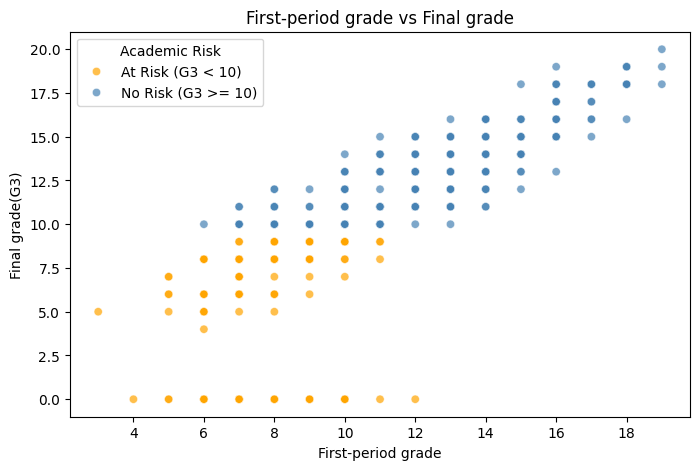

In [45]:
# Create descriptive labels for academic risk
df['risk_label'] = df['academic_risk'].map({
    0: 'No Risk (G3 >= 10)',
    1: 'At Risk (G3 < 10)'
})
plt.figure(figsize=(8,5))
sns.scatterplot(
    data =df,
    x= 'G1',
    y='G3',
    hue = 'risk_label',
    alpha =0.7,
    palette={'No Risk (G3 >= 10)':'steelblue', 'At Risk (G3 < 10)':'orange'},


)
plt.title('First-period grade vs Final grade')
plt.xlabel('First-period grade')
plt.ylabel('Final grade(G3)')
plt.legend(title = 'Academic Risk')
plt.show()

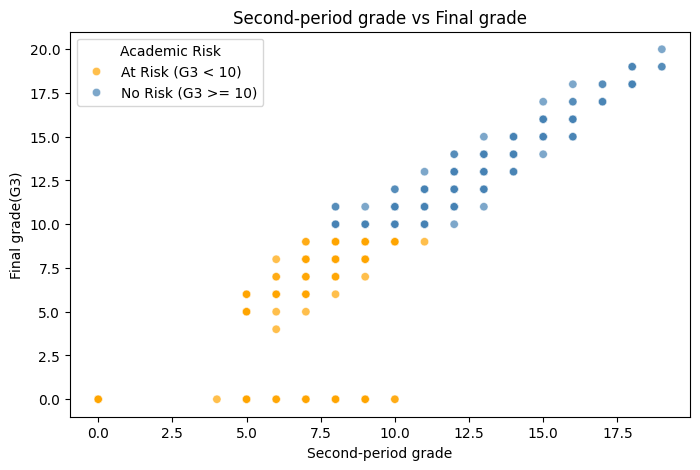

In [46]:
#Create descriptive labels for academic risk
df['risk_label'] = df['academic_risk'].map({
    0: 'No Risk (G3 >= 10)',
    1: 'At Risk (G3 < 10)'
})
plt.figure(figsize=(8,5))
sns.scatterplot(
    data =df,
    x= 'G2',
    y='G3',
    hue = 'risk_label',
    alpha =0.7,
    palette={'No Risk (G3 >= 10)':'steelblue', 'At Risk (G3 < 10)':'orange'},


)
plt.title('Second-period grade vs Final grade')
plt.xlabel('Second-period grade')
plt.ylabel('Final grade(G3)')
plt.legend(title = 'Academic Risk')
plt.show()

In [47]:
df['grade_change']=df['G2']-df['G1']
display(df[['G1', 'G2', 'grade_change','G3']].head())

,G1,G2,grade_change,G3
0,5,6,1,6
1,5,5,0,6
2,7,8,1,10
3,15,14,-1,15
4,6,10,4,10


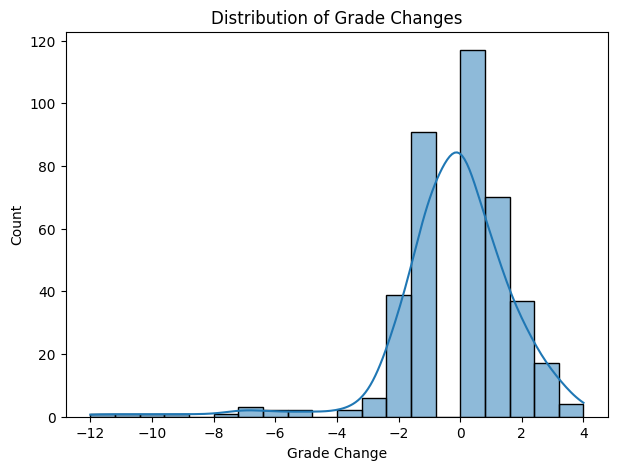

In [48]:
plt.figure(figsize=(7,5))
sns.histplot(data=df,
             x=df['grade_change'], bins=20, kde=True)
plt.xlabel('Grade Change')
plt.ylabel('Count')
plt.title('Distribution of Grade Changes')
plt.show()

In [49]:
gra_change_summay = (
    df.groupby('academic_risk')['grade_change'].agg(['count', 'mean', 'median', 'std']).round(2)
)
display(gra_change_summay
)

,count,mean,median,std
academic_risk,,,,
0,265,0.17,0.0,1.43
1,130,-0.94,-1.0,2.62


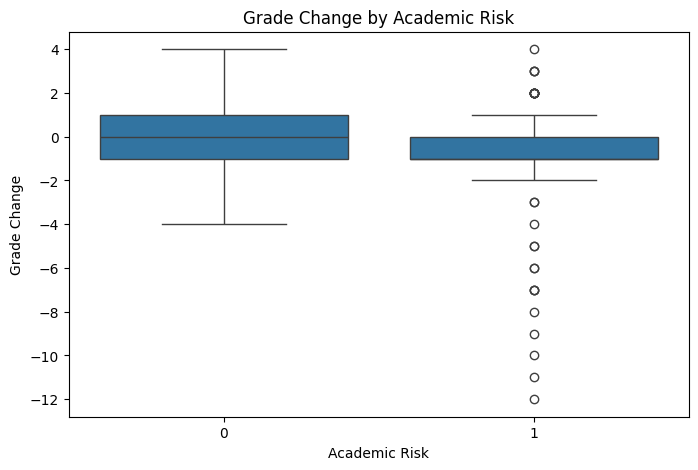

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(data =df,
            x= 'academic_risk',
            y='grade_change')
plt.xlabel('Academic Risk')
plt.ylabel('Grade Change')
plt.title('Grade Change by Academic Risk')
plt.show()

In [51]:
study_risk_summary= (
    df.groupby('studytime').agg(
        total_students=('academic_risk', 'size'),
        at_risk_students=('academic_risk', 'sum'),
        risk_percentage=('academic_risk', 'mean')
    )
)
study_risk_summary['risk_percentage'] *=100
display(study_risk_summary)
#print(study_risk_summary.to_markdown())

,total_students,at_risk_students,risk_percentage
studytime,,,
1,105,37,35.238095
2,198,70,35.353535
3,65,16,24.615385
4,27,7,25.925926


In [52]:
pd.crosstab(
    df['studytime'],
    df['G3'] == 0,
    normalize='index'
).round(3) * 100

G3,False,True
studytime,,
1,87.6,12.4
2,91.9,8.1
3,90.8,9.2
4,88.9,11.1


In [53]:
# selective feature columns for ML model training
feature_cols=[
    'G1', 'failures', 'studytime', 'schoolsup',
    'famsup', 'higher', 'health', 'traveltime']
X = df[feature_cols].copy()
y = df['academic_risk'].copy()
print('Feature Materix Shape:', X.shape)
print('Target shape:', y.shape)

Feature Materix Shape: (395, 8)
Target shape: (395,)


In [54]:
print(df.isnull().sum().sum())
X.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   G1          395 non-null    int64 
 1   failures    395 non-null    int64 
 2   studytime   395 non-null    int64 
 3   schoolsup   395 non-null    object
 4   famsup      395 non-null    object
 5   higher      395 non-null    object
 6   health      395 non-null    int64 
 7   traveltime  395 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 24.8+ KB


In [55]:
#numerical features and categorical features
# Only first-period grade is included
numerical_features=['G1', 'failures', 'studytime', 'health', 'traveltime']
categorical_features=['schoolsup', 'famsup', 'higher']


In [56]:
print(feature_cols)

['G1', 'failures', 'studytime', 'schoolsup', 'famsup', 'higher', 'health', 'traveltime']


In [57]:
#train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)
print

Training set shape: (316, 8)
Testing set shape: (79, 8)


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [58]:
print("training set class distribution:")
print(y_train.value_counts())
print("\nTesting set class distribution:")
print(y_test.value_counts())

training set class distribution:
academic_risk
0    212
1    104
Name: count, dtype: int64

Testing set class distribution:
academic_risk
0    53
1    26
Name: count, dtype: int64


In [59]:
#applying tranformers
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators =200,
                                          random_state=42, class_weight='balanced'))
])

In [61]:
# train the model
rf_pipeline.fit(X_train, y_train)


print('Training, accuracy:', rf_pipeline.score(X_train, y_train) )

Training, accuracy: 0.9683544303797469


In [62]:
y_pred=rf_pipeline.predict(X_test)

In [63]:
y_prob=rf_pipeline.predict_proba(X_test)[:,1]

In [64]:
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
print("Accuracy:", round(accuracy_score(y_test, y_pred),2))
print("Precision:", round(precision_score(y_test, y_pred),2))
print("Recall:", round(recall_score(y_test, y_pred),2))
print("F1 Score:", round(f1_score(y_test, y_pred),2))

Accuracy: 0.81
Precision: 0.74
Recall: 0.65
F1 Score: 0.69


In [65]:
report1=classification_report(y_test, y_pred, output_dict=True)
report1_df=pd.DataFrame(report1).transpose()
display(report1_df.round(3))
#print(report1_df.round(3).to_markdown())

,precision,recall,f1-score,support
0,0.839,0.887,0.862,53.00
1,0.739,0.654,0.694,26.00
accuracy,0.810,0.810,0.810,0.81
macro avg,0.789,0.770,0.778,79.00
weighted avg,0.806,0.810,0.807,79.00


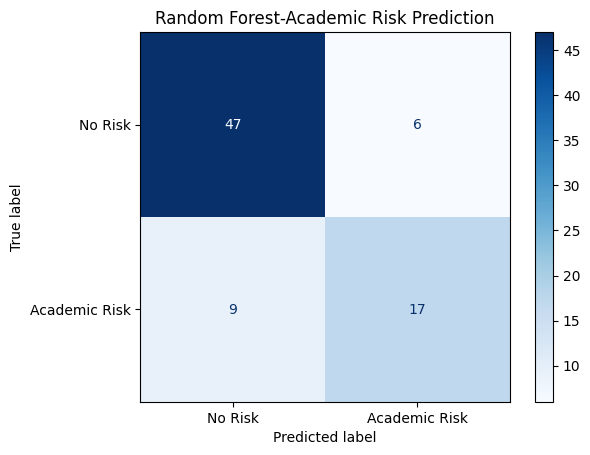

In [66]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        cmap='Blues', display_labels=['No Risk', "Academic Risk"])
plt.title('Random Forest-Academic Risk Prediction')
plt.show()

In [67]:
from sklearn.dummy import DummyClassifier


In [68]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

In [69]:
print("Baseline Accuracy", accuracy_score(y_test, y_pred_baseline))
print("Baseline Precision", precision_score(y_test, y_pred_baseline, zero_division=0),)
print("Baseline Recall", recall_score(y_test, y_pred_baseline))
print("Baseline F1 Score", f1_score(y_test, y_pred_baseline))


Baseline Accuracy 0.6708860759493671
Baseline Precision 0.0
Baseline Recall 0.0
Baseline F1 Score 0.0


In [70]:
print(classification_report(y_test, y_pred_baseline, zero_division=0))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        53
           1       0.00      0.00      0.00        26

    accuracy                           0.67        79
   macro avg       0.34      0.50      0.40        79
weighted avg       0.45      0.67      0.54        79



In [71]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_pipeline, X_test, y_test, n_repeats=20, random_state=42, scoring='f1'
)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

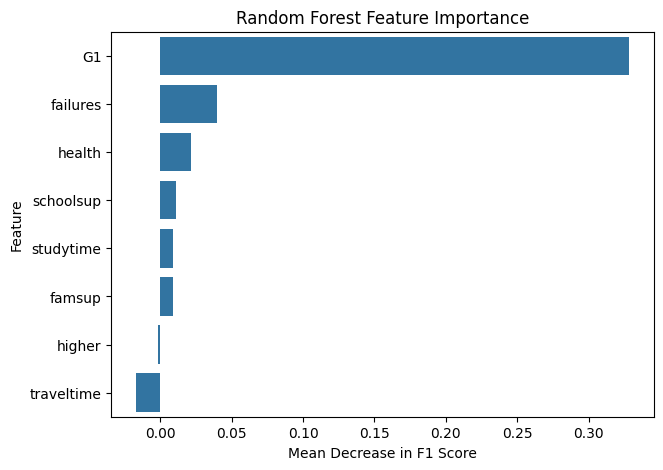

In [72]:
plt.figure(figsize=(7, 5))
sns.barplot(data=feature_importance,
            x='Importance',
            y='Feature')

plt.title('Random Forest Feature Importance')
plt.xlabel('Mean Decrease in F1 Score')
plt.ylabel('Feature')
plt.show()

In [73]:
display(feature_importance)

,Feature,Importance,Std
0,G1,0.328239,0.058599
1,failures,0.039774,0.028538
6,health,0.021667,0.048781
3,schoolsup,0.010768,0.032152
2,studytime,0.008796,0.025625
4,famsup,0.008611,0.035478
5,higher,-0.001335,0.007240
7,traveltime,-0.017121,0.022139


In [74]:
from sklearn.model_selection import(StratifiedKFold, cross_validate)
cv = StratifiedKFold(
    shuffle=True,
    random_state=42,
    n_splits=5
)

scoring={
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}
cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [75]:
cv_summary= pd.DataFrame({
    'Metric': list(scoring.keys()),
    'Mean': [
        cv_results[f'test_{metric}'].mean()
        for metric in scoring
    ],
    'Std': [
        cv_results[f'test_{metric}'].std()
        for metric in scoring
    ]
})
display(cv_summary.round(3))
#print(cv_summary.round(3).to_markdown())

,Metric,Mean,Std
0,accuracy,0.794,0.026
1,precision,0.693,0.064
2,recall,0.704,0.120
3,f1,0.689,0.050


In [76]:
test_results = X_test.copy()
test_results['actual_risk'] = y_test
test_results['predicted_risk'] = y_pred
test_results['risk_prob'] = y_prob

test_results['G3']=df.loc[X_test.index, 'G3']
test_results['academic_risk']=df.loc[X_test.index, 'academic_risk']
false_negatives = test_results[
    (test_results['actual_risk'] == 1) & (test_results['predicted_risk'] == 0)
]
print(f'Number of False Negatives: {len(false_negatives)}')

Number of False Negatives: 9


In [77]:
display(false_negatives.sort_values(by='risk_prob', ascending=False))

,G1,failures,studytime,schoolsup,famsup,higher,health,traveltime,actual_risk,predicted_risk,risk_prob,G3,academic_risk
82,7,0,2,no,yes,yes,5,1,1,0,0.485074,6,1
0,5,0,2,yes,no,yes,3,2,1,0,0.397524,6,1
347,10,0,3,no,yes,yes,5,1,1,0,0.338215,9,1
328,10,0,3,no,yes,yes,4,1,1,0,0.286157,9,1
44,10,1,2,yes,no,yes,5,2,1,0,0.185000,9,1
263,10,0,3,no,no,yes,4,1,1,0,0.181021,9,1
183,9,0,2,no,yes,yes,1,1,1,0,0.164957,8,1
334,10,0,4,no,no,yes,4,2,1,0,0.149015,0,1
135,11,0,3,no,yes,yes,5,1,1,0,0.013354,0,1


In [78]:
false_negatives.describe()

,G1,failures,studytime,health,traveltime,actual_risk,predicted_risk,risk_prob,G3,academic_risk
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.0,9.0,9.000000,9.000000,9.0
mean,9.111111,0.111111,2.666667,4.000000,1.333333,1.0,0.0,0.244480,6.222222,1.0
std,1.900292,0.333333,0.707107,1.322876,0.500000,0.0,0.0,0.145023,3.734226,0.0
min,5.000000,0.000000,2.000000,1.000000,1.000000,1.0,0.0,0.013354,0.000000,1.0
25%,9.000000,0.000000,2.000000,4.000000,1.000000,1.0,0.0,0.164957,6.000000,1.0
50%,10.000000,0.000000,3.000000,4.000000,1.000000,1.0,0.0,0.185000,8.000000,1.0
75%,10.000000,0.000000,3.000000,5.000000,2.000000,1.0,0.0,0.338215,9.000000,1.0
max,11.000000,1.000000,4.000000,5.000000,2.000000,1.0,0.0,0.485074,9.000000,1.0


In [79]:
from sklearn.linear_model import LogisticRegression
#numerical preprocessing
lr_numerical_transformer = Pipeline(
    steps = [
        ('scaler', StandardScaler())
    ]
)
#categorical preprocessing
lr_categorical_transformer = Pipeline(
    steps = [
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

#combine preprocessing
lr_preprocessor = ColumnTransformer(
    transformers=[
        ('num', lr_numerical_transformer, numerical_features),
        ('cat', lr_categorical_transformer, categorical_features)
    ])
# logistic regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
print("Logistic Pipeline Created")


Logistic Pipeline Created


In [80]:
#logistic regression cross vlaidation
lr_cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

#summarize results
lr_cv_summary= pd.DataFrame({
    'Metric': list(scoring.keys()),
    'Mean': [
        lr_cv_results[f'test_{metric}'].mean()
        for metric in scoring
    ],
    'Std': [
        lr_cv_results[f'test_{metric}'].std()
        for metric in scoring
    ]
})
display(lr_cv_summary.round(3))
#print(lr_cv_summary.round(3).to_markdown())


,Metric,Mean,Std
0,accuracy,0.817,0.058
1,precision,0.691,0.096
2,recall,0.847,0.069
3,f1,0.756,0.063


In [81]:
rf_comparison = cv_summary.copy()
rf_comparison['Model'] = 'Random Forest'
lr_comparison = lr_cv_summary.copy()
lr_comparison['Model'] = 'Logistic Regression'
#combine results
model_comparison=pd.concat(
    [rf_comparison, lr_comparison],
    ignore_index=True
)
display(model_comparison[['Model', 'Metric', 'Mean', 'Std']].round(3))


,Model,Metric,Mean,Std
0,Random Forest,accuracy,0.794,0.026
1,Random Forest,precision,0.693,0.064
2,Random Forest,recall,0.704,0.120
3,Random Forest,f1,0.689,0.050
4,Logistic Regression,accuracy,0.817,0.058
5,Logistic Regression,precision,0.691,0.096
6,Logistic Regression,recall,0.847,0.069
7,Logistic Regression,f1,0.756,0.063


In [82]:
feature_cols_2 = feature_cols+['G2', 'grade_change']
X2 = df[feature_cols_2].copy()
y2 = df['academic_risk'].copy()
print('Feature Materix Shape:', X2.shape)
print('Target shape:', y2.shape)


Feature Materix Shape: (395, 10)
Target shape: (395,)


In [83]:
X2_train = X2.loc[X_train.index].copy()
X2_test = X2.loc[X_test.index].copy()
y2_train = y2.loc[y_train.index].copy()
y2_test = y2.loc[y_test.index].copy()
print('Training set shape - Model2:', X2_train.shape)
print('Testing set shape - Model2:', X2_test.shape)

# veridy matching indices
assert X2_train.index.equals(X_train.index)
assert X2_test.index.equals(X_test.index)
assert y2_train.index.equals(y_train.index)
assert y2_test.index.equals(y_test.index)


Training set shape - Model2: (316, 10)
Testing set shape - Model2: (79, 10)


In [84]:
## Createing model2 RandomForest pipeline
numerical_features2 = numerical_features+['G2', 'grade_change']

preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features2),
        ('cat', categorical_transformer, categorical_features)
    ])
rf_pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor2),
    ('classifier', RandomForestClassifier(n_estimators =200,
                                          random_state=42, class_weight='balanced'))
])
print("Model2 pipeleine created successfully")

Model2 pipeleine created successfully


In [85]:
cv_results2 = cross_validate(
    rf_pipeline2,
    X2_train,
    y2_train,
    cv=cv,
    scoring=scoring,
    n_jobs =-1
)

cv_summary2 = pd.DataFrame({'Metric': list(scoring.keys()),
                            'Mean': [cv_results2[f'test_{metric}'].mean()
                                     for metric in scoring],
                            'Std': [cv_results2[f'test_{metric}'].std()
                                    for metric in scoring]
                           })
display(cv_summary2.round(3))
#print(cv_summary2.round(3).to_markdown())

,Metric,Mean,Std
0,accuracy,0.902,0.025
1,precision,0.832,0.047
2,recall,0.886,0.077
3,f1,0.855,0.040


In [86]:
cv_summary

,Metric,Mean,Std
0,accuracy,0.794345,0.026179
1,precision,0.693490,0.064469
2,recall,0.703810,0.120407
3,f1,0.689214,0.050173


In [87]:
# Combine model1 and 2
comparison_1 = cv_summary.copy()
comparison_1['Model'] = 'Model1-G1'
comparison_2 = cv_summary2.copy()
comparison_2['Model'] = 'Model2 -G2'
comparison_12 = pd.concat(
    [comparison_1, comparison_2],
    ignore_index=True
)
display(comparison_12.round(3))



,Metric,Mean,Std,Model
0,accuracy,0.794,0.026,Model1-G1
1,precision,0.693,0.064,Model1-G1
2,recall,0.704,0.120,Model1-G1
3,f1,0.689,0.050,Model1-G1
4,accuracy,0.902,0.025,Model2 -G2
5,precision,0.832,0.047,Model2 -G2
6,recall,0.886,0.077,Model2 -G2
7,f1,0.855,0.040,Model2 -G2


In [88]:
print("Train1: ", X_train.shape)
print("Train2: ", X2_train.shape)

Train1:  (316, 8)
Train2:  (316, 10)


In [89]:
lr_preprocessor2 = ColumnTransformer(
    transformers=[
        ('num', lr_numerical_transformer, numerical_features2),
        ('cat', lr_categorical_transformer, categorical_features)
    ])
lr_pipeline2 = Pipeline(steps=[
    ('preprocessor', lr_preprocessor2),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
print("Logistic Pipeline Model-2 Created")

Logistic Pipeline Model-2 Created


In [90]:
lr_cv_results2 = cross_validate(
    lr_pipeline2,
    X2_train,
    y2_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
lr_cv_summary2 = pd.DataFrame({
    'Metric': list(scoring.keys()),
    'Mean': [
        lr_cv_results2[f'test_{metric}'].mean()
        for metric in scoring
    ],
    'Std': [
        lr_cv_results2[f'test_{metric}'].std()
        for metric in scoring
    ]
})
display(lr_cv_summary2.round(3))
#print(lr_cv_summary2.round(3).to_markdown())

,Metric,Mean,Std
0,accuracy,0.889,0.029
1,precision,0.795,0.065
2,recall,0.905,0.052
3,f1,0.844,0.039


In [91]:
## Model 3
feature_cols3 = feature_cols+['G2']
numerical_features3 = numerical_features+['G2']
X3 = df[feature_cols3].copy()
y3 = df['academic_risk'].copy()
print('Feature Materix Shape:', X3.shape)
print('Target shape:', y3.shape)

Feature Materix Shape: (395, 9)
Target shape: (395,)


In [92]:
X3_train = X3.loc[X_train.index].copy()
X3_test = X3.loc[X_test.index].copy()
y3_train = y3.loc[y_train.index].copy()
y3_test = y3.loc[y_test.index].copy()
print('Training set shape - Model3:', X3_train.shape)
print('Testing set shape - Model3:', X3_test.shape)

Training set shape - Model3: (316, 9)
Testing set shape - Model3: (79, 9)


In [93]:
## Random Forest pipeline - Model3
preprocessor3 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features3),
        ('cat', categorical_transformer, categorical_features)
    ])
rf_pipeline3 = Pipeline(steps=[
    ('preprocessor', preprocessor3),
    ('classifier', RandomForestClassifier(n_estimators =200,
                                          random_state=42, class_weight='balanced'))
])


In [94]:
# Cross validation -Model 3
cv_results_model3 = cross_validate(
    rf_pipeline3,
    X3_train,
    y3_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_summary_model3 = pd.DataFrame({
    'Metric': list(scoring.keys()),
    'With Grade change': [
        cv_results2[f'test_{metric}'].mean()
        for metric in scoring
    ],
    'Without Grade change': [
        cv_results_model3[f'test_{metric}'].mean()
        for metric in scoring
    ]
})
display(cv_summary_model3.round(3))
#print(cv_summary_model3.round(3).to_markdown())


,Metric,With Grade change,Without Grade change
0,accuracy,0.902,0.896
1,precision,0.832,0.829
2,recall,0.886,0.867
3,f1,0.855,0.844


In [95]:
cv_summary_rf3 = pd.DataFrame({
    'Metric': list(scoring.keys()),
    'Mean': [
        cv_results_model3[f'test_{metric}'].mean()
        for metric in scoring
    ],
    'Std': [
        cv_results_model3[f'test_{metric}'].std()
        for metric in scoring
    ]
})
display(cv_summary_rf3.round(3))
#print(cv_summary_rf3.round(3).to_markdown())

,Metric,Mean,Std
0,accuracy,0.896,0.027
1,precision,0.829,0.046
2,recall,0.867,0.092
3,f1,0.844,0.045


In [96]:
final_modelA = lr_pipeline

final_modelA.fit(X_train, y_train)
y_pred_finalA = final_modelA.predict(X_test)
y_prob_finalA = final_modelA.predict_proba(X_test)[:,1]

In [97]:
final_modelB = rf_pipeline2
final_modelB.fit(X2_train, y2_train)
y_pred_finalB = final_modelB.predict(X2_test)
y_prob_finalB = final_modelB.predict_proba(X2_test)[:,1]

In [98]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    return{
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0)
    }

resultsA = evaluate_model(y_test, y_pred_finalA, y_prob_finalA, 'Logistic Regression')
resultsB = evaluate_model(y2_test, y_pred_finalB, y_prob_finalB, 'Random Forest')

In [99]:
test_comparison = pd.DataFrame(
    [resultsA, resultsB],
    #columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)
display(test_comparison.round(3))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.848,0.733,0.846,0.786
1,Random Forest,0.924,0.955,0.808,0.875


In [100]:
cmA =confusion_matrix(y_test, y_pred_finalA)
cmB = confusion_matrix(y2_test, y_pred_finalB)

print("ModelA Confusion Matrix:")
print(cmA)
print("\nModelB Confusion Matrix:")
print(cmB)

ModelA Confusion Matrix:
[[45  8]
 [ 4 22]]

ModelB Confusion Matrix:
[[52  1]
 [ 5 21]]


Among students who received final grades below 10 and were missed by the first-period model, how many were correctly identified by the updated second-period model?

In [101]:
student_predictions = pd.DataFrame({'G1': df.loc[X_test.index, 'G1'],
                                   'G2':df.loc[X_test.index, 'G2'],
                                   'G3':df.loc[X_test.index, 'G3'],
                                   'grade_change': df.loc[X_test.index, 'grade_change'],
                                   'actual_risk':y_test,
                                   'pred_A': y_pred_finalA,
                                   'pred_B': y_pred_finalB,
                                   'prob_A':y_prob_finalA,
                                   'prob_B':y_prob_finalB })

In [102]:
missed_by_A = student_predictions[(student_predictions['actual_risk'] == 1) & (student_predictions['pred_A'] == 0)]

In [103]:
missed_by_A

,G1,G2,G3,grade_change,actual_risk,pred_A,pred_B,prob_A,prob_B
297,10,8,8,-2,1,0,1,0.412764,0.980000
135,11,0,0,-11,1,0,1,0.329253,0.835000
263,10,9,9,-1,1,0,1,0.448507,0.516719
44,10,10,9,0,1,0,0,0.436165,0.237370


In [104]:
student_predictions['pred_B']

,pred_B
383,1
19,0
193,0
343,1
92,1
...,...
348,0
315,0
331,0
380,0


In [105]:
identified_by_B = missed_by_A[missed_by_A['pred_B']==1].copy()
print("students missed by Model A : ", len(missed_by_A))
print("students missed by A \n but dentified by Model B : ", len(identified_by_B))

students missed by Model A :  4
students missed by A 
 but dentified by Model B :  3


In [106]:
identified_by_B

,G1,G2,G3,grade_change,actual_risk,pred_A,pred_B,prob_A,prob_B
297,10,8,8,-2,1,0,1,0.412764,0.980000
135,11,0,0,-11,1,0,1,0.329253,0.835000
263,10,9,9,-1,1,0,1,0.448507,0.516719


In [107]:
display(
    identified_by_B[
        [
            'G1', 'G2', 'G3', 'grade_change', 'actual_risk', 'pred_A', 'prob_A', 'pred_B', 'prob_B'
        ]
    ]
)

,G1,G2,G3,grade_change,actual_risk,pred_A,prob_A,pred_B,prob_B
297,10,8,8,-2,1,0,0.412764,1,0.980000
135,11,0,0,-11,1,0,0.329253,1,0.835000
263,10,9,9,-1,1,0,0.448507,1,0.516719


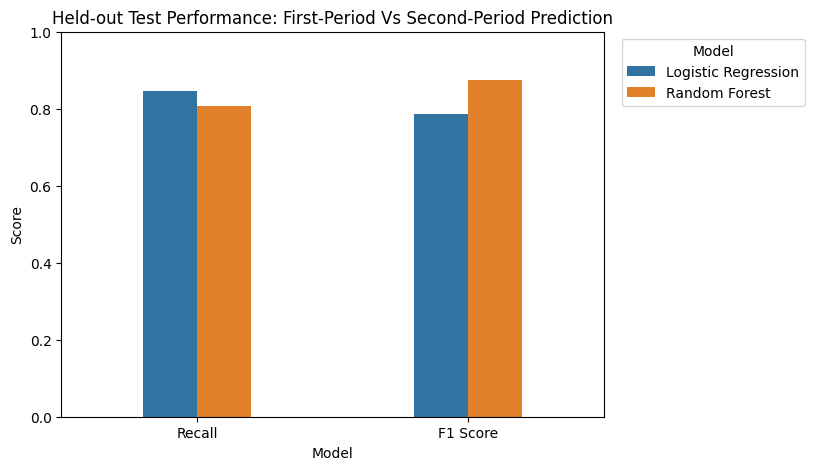

In [108]:
plot_df = test_comparison.melt(
    id_vars=['Model'],
    value_vars=['Recall', 'F1 Score'],
    var_name='Metric',
    value_name='Score'
)
plt.figure(figsize=(7, 5))
sns.barplot(
    data=plot_df,
    x='Metric',
    y='Score',
    hue='Model',
    width=0.4,
    errorbar=None,
    legend = True

)
plt.title('Held-out Test Performance: '
           'First-Period Vs Second-Period Prediction')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0,1)
plt.legend(title='Model', bbox_to_anchor = (1.02, 1), loc = 'upper left')


In [109]:
plot_df

,Model,Metric,Score
0,Logistic Regression,Recall,0.846154
1,Random Forest,Recall,0.807692
2,Logistic Regression,F1 Score,0.785714
3,Random Forest,F1 Score,0.875000


In [110]:
X_test.shape

(79, 8)

In [111]:
tutoring_capacity = 20
flagged_A = (y_pred_finalA == 1).sum()
flagged_B = (y_pred_finalB == 1).sum()
print(f'Students Flagged by ModelA: {flagged_A}')
print(f'Students Flagged by ModelB: {flagged_B}')
print('Available tutoring placess:', tutoring_capacity)

Students Flagged by ModelA: 30
Students Flagged by ModelB: 22
Available tutoring placess: 20


In [112]:
def evaluate_thresholds(y_true, risk_score, thresholds):
    results=[]
    for threshold in thresholds:
        y_pred_threshold = (risk_score >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred_threshold,
            labels=[0, 1]
            ).ravel()

        results.append(
            {
              'Threshold': threshold,
              'Students_Flagged': int(tp+fp),
              'True_Positives': int (tp),
              'False_Positives': int(fp),
              'True_Negatives': int(tn),
              'False_Negatives': int(fn),
              'Precision': precision_score(y_true,
                                           y_pred_threshold,
                                           zero_division=0),
              'Recall': recall_score(y_true,
                                    y_pred_threshold,
                                    zero_division=0),
              'F1_Score': f1_score(
                                   y_true,
                                   y_pred_threshold,
                                   zero_division=0)
            }
        )
    return pd.DataFrame(results)

In [113]:
thresholds =[0.30, 0.40, 0.50, 0.60, 0.70]
threshold_resultsA = evaluate_thresholds(y_test,
                                   y_prob_finalA,
                                   thresholds)
display(threshold_resultsA.round(3))

,Threshold,Students_Flagged,True_Positives,False_Positives,True_Negatives,False_Negatives,Precision,Recall,F1_Score
0,0.3,40,26,14,39,0,0.650,1.000,0.788
1,0.4,36,25,11,42,1,0.694,0.962,0.806
2,0.5,30,22,8,45,4,0.733,0.846,0.786
3,0.6,26,19,7,46,7,0.731,0.731,0.731
4,0.7,20,16,4,49,10,0.800,0.615,0.696


In [114]:
threshold_resultsB = evaluate_thresholds(
    y2_test,
    y_prob_finalB,
    thresholds
)

display(threshold_resultsB.round(3))

,Threshold,Students_Flagged,True_Positives,False_Positives,True_Negatives,False_Negatives,Precision,Recall,F1_Score
0,0.3,28,22,6,47,4,0.786,0.846,0.815
1,0.4,25,21,4,49,5,0.840,0.808,0.824
2,0.5,22,21,1,52,5,0.955,0.808,0.875
3,0.6,20,20,0,53,6,1.000,0.769,0.870
4,0.7,19,19,0,53,7,1.000,0.731,0.844


In [115]:
plotA = threshold_resultsA[
    ['Threshold', 'Students_Flagged']
].copy()
plotA['Model'] = 'ModelA'
plotB = threshold_resultsB[
    ['Threshold', 'Students_Flagged']
].copy()
plotB['Model'] = 'ModelB'


In [116]:
threshold_plot_df = pd.concat(
    [plotA, plotB],
    ignore_index=True
)

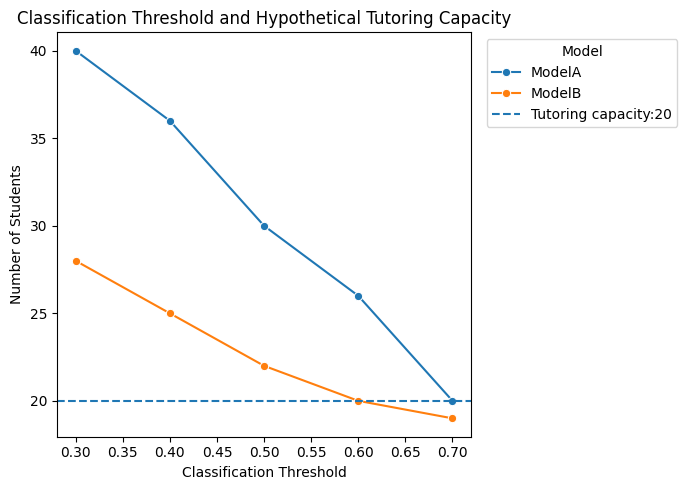

In [117]:
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=threshold_plot_df,
    x='Threshold',
    y='Students_Flagged',
    hue='Model',
    marker='o')

plt.axhline(
     y = tutoring_capacity,
     linestyle='--',
     label='Tutoring capacity:20'
)
plt.title(
    'Classification Threshold and '
    'Hypothetical Tutoring Capacity'
)
plt.xlabel('Classification Threshold')
plt.ylabel('Number of Students')
plt.legend(title='Model', bbox_to_anchor = (1.02, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

In [118]:
planning_A = threshold_resultsA.copy()
planning_A['Model'] = 'ModelA'
planning_B = threshold_resultsB.copy()
planning_B['Model'] = 'ModelB'
planning_A['Capacity'] =tutoring_capacity
planning_A['Additional_places_needed'] = (
    planning_A['Students_Flagged'] - tutoring_capacity
)
planning_B['Capacity'] = tutoring_capacity
planning_B['Additional_places_needed'] = (
    planning_B['Students_Flagged'] - tutoring_capacity
).clip(lower=0)

# Add capacity information to Model B

planning_df = pd.concat(
    [planning_A, planning_B],
    ignore_index=True)

# Add Capacity

planning_B = threshold_resultsB.copy()
planning_B['Model'] = 'ModelB'
planning_B['Capacity'] = tutoring_capacity
planning_B['Additional_places_needed'] = (
    planning_B['Students_Flagged'] - tutoring_capacity
).clip(lower=0)

resource_planning = pd.concat(
    [planning_A, planning_B],
    ignore_index=True
)
display(resource_planning[
    ['Model',
     'Threshold',
     'Students_Flagged',
     'Capacity',
     'True_Positives',
     'False_Negatives',
     'Additional_places_needed']
])


,Model,Threshold,Students_Flagged,Capacity,True_Positives,False_Negatives,Additional_places_needed
0,ModelA,0.3,40,20,26,0,20
1,ModelA,0.4,36,20,25,1,16
2,ModelA,0.5,30,20,22,4,10
3,ModelA,0.6,26,20,19,7,6
4,ModelA,0.7,20,20,16,10,0
5,ModelB,0.3,28,20,22,4,8
6,ModelB,0.4,25,20,21,5,5
7,ModelB,0.5,22,20,21,5,2
8,ModelB,0.6,20,20,20,6,0
9,ModelB,0.7,19,20,19,7,0


In [119]:
student_predictions['risk_transition'] = np.select(
    [
        (student_predictions['pred_A'] == 1) & (student_predictions['pred_B'] == 1),
        (student_predictions['pred_A'] == 1) & (student_predictions['pred_B'] == 0),
        (student_predictions['pred_A'] == 0) & (student_predictions['pred_B'] == 1),
        (student_predictions['pred_A'] == 0) & (student_predictions['pred_B'] == 0)],
    ['Flagged by both models',
     'Flagged by model A',
     'Flagged by model B',
     'Not flagged by either'],
    default='Unknown'
)

transition_counts = student_predictions['risk_transition'].value_counts().reindex(
    [
        'Flagged by both models',
        'Flagged by model A',
        'Flagged by model B',
        'Not flagged by either'
    ], fill_value=0
)
display(transition_counts)

,count
risk_transition,
Flagged by both models,18
Flagged by model A,12
Flagged by model B,4
Not flagged by either,45


In [120]:
transition_summary = (
                    student_predictions
                    .groupby('risk_transition')
                    .agg(students = ('actual_risk', 'size'),
                          actual_at_risk=('actual_risk', 'sum')
                         )
                          .reindex(['Flagged by both models',
                                    'Flagged by model A',
                                     'Flagged by model B',
                                      'Not flagged by either'])
                              )

In [121]:
display(transition_summary)

,students,actual_at_risk
risk_transition,,
Flagged by both models,18,18
Flagged by model A,12,4
Flagged by model B,4,3
Not flagged by either,45,1


In [122]:
transition_summary['actual_not_at_risk']=(
    transition_summary['students']-
    transition_summary['actual_at_risk']
)
display(transition_summary)


,students,actual_at_risk,actual_not_at_risk
risk_transition,,,
Flagged by both models,18,18,0
Flagged by model A,12,4,8
Flagged by model B,4,3,1
Not flagged by either,45,1,44


In [123]:
transition_summary['actual_at_risk_pct']=(
    transition_summary['actual_at_risk']*100/
    transition_summary['students']
).round(1)
display(transition_summary)

,students,actual_at_risk,actual_not_at_risk,actual_at_risk_pct
risk_transition,,,,
Flagged by both models,18,18,0,100.0
Flagged by model A,12,4,8,33.3
Flagged by model B,4,3,1,75.0
Not flagged by either,45,1,44,2.2


In [124]:
transition_table = pd.crosstab(
    student_predictions['pred_A'],
    student_predictions['pred_B'],

)
transition_table.index = [
    'Model A: Not flagged',
    'Model A: Flagged'
]
transition_table.columns = [
    'Model B: Not flagged',
    'Model B: Flagged'
]
display(transition_table)


,Model B: Not flagged,Model B: Flagged
Model A: Not flagged,45,4
Model A: Flagged,12,18


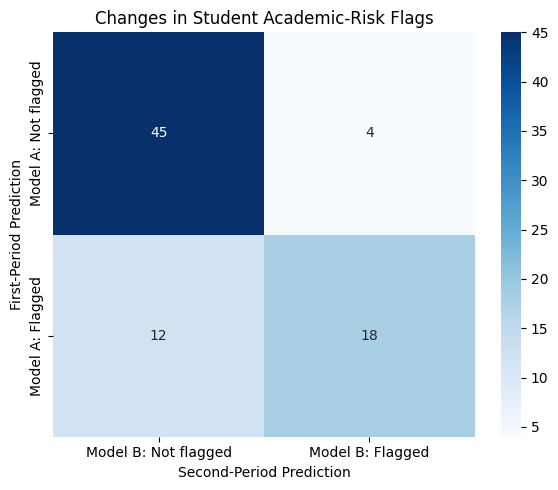

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    transition_table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Changes in Student Academic-Risk Flags')
plt.xlabel('Second-Period Prediction')
plt.ylabel('First-Period Prediction')

plt.tight_layout()
plt.show()

In [126]:
newly_flagged = student_predictions[
    student_predictions['risk_transition']
    == 'Flagged by model B'
].copy()

display(
    newly_flagged[
        [
            'G1',
            'G2',
            'grade_change',
            'G3',
            'actual_risk',
            'prob_A',
            'prob_B'
        ]
    ].sort_values('grade_change')
)

,G1,G2,grade_change,G3,actual_risk,prob_A,prob_B
135,11,0,-11,0,1,0.329253,0.835000
297,10,8,-2,8,1,0.412764,0.980000
263,10,9,-1,9,1,0.448507,0.516719
284,10,9,-1,11,0,0.466556,0.579723


In [127]:
student_predictions

,G1,G2,G3,grade_change,actual_risk,pred_A,pred_B,prob_A,prob_B,risk_transition
383,6,5,0,-1,1,1,1,0.954731,0.990000,Flagged by both models
19,8,10,10,2,0,1,0,0.733122,0.201709,Flagged by model A
193,8,9,10,1,0,1,0,0.783230,0.458354,Flagged by model A
343,9,8,0,-1,1,1,1,0.737634,0.925878,Flagged by both models
92,7,6,6,-1,1,1,1,0.880562,0.980000,Flagged by both models
...,...,...,...,...,...,...,...,...,...,...
348,13,15,15,2,0,0,0,0.079032,0.000000,Not flagged by either
315,13,11,11,-2,0,0,0,0.082950,0.020000,Not flagged by either
331,12,14,14,2,0,0,0,0.174719,0.000000,Not flagged by either
380,15,14,14,-1,0,0,0,0.008170,0.000000,Not flagged by either


In [128]:
transition_summary

,students,actual_at_risk,actual_not_at_risk,actual_at_risk_pct
risk_transition,,,,
Flagged by both models,18,18,0,100.0
Flagged by model A,12,4,8,33.3
Flagged by model B,4,3,1,75.0
Not flagged by either,45,1,44,2.2


In [129]:
threshold = 0.50

student_predictions['flag_A_05'] = (
    student_predictions['prob_A'] >= threshold
).astype(int)

student_predictions['flag_B_05'] = (
    student_predictions['prob_B'] >= threshold
).astype(int)

In [130]:
student_predictions['risk_transition_05'] = np.select(
    [
        (student_predictions['flag_A_05'] == 1) &
        (student_predictions['flag_B_05'] == 1),

        (student_predictions['flag_A_05'] == 1) &
        (student_predictions['flag_B_05'] == 0),

        (student_predictions['flag_A_05'] == 0) &
        (student_predictions['flag_B_05'] == 1),

        (student_predictions['flag_A_05'] == 0) &
        (student_predictions['flag_B_05'] == 0)
    ],
    [
        'Flagged by both models',
        'Flagged only by Model A',
        'Newly flagged by Model B',
        'Not flagged by either'
    ],
    default='Unknown'
)

In [131]:
group_order = [
    'Flagged by both models',
    'Flagged only by Model A',
    'Newly flagged by Model B',
    'Not flagged by either'
]

transition_table = (
    student_predictions
    .groupby('risk_transition_05')
    .agg(
        number_of_students=('actual_risk', 'size'),
        students_with_G3_below_10=('actual_risk', 'sum')
    )
    .reindex(group_order, fill_value=0)
)

transition_table.index.name = 'Prediction group'

transition_table = transition_table.rename(
    columns={
        'number_of_students': 'Number of students',
        'students_with_G3_below_10': 'Students with G3 < 10'
    }
)

print(transition_table.to_markdown())

| Prediction group         |   Number of students |   Students with G3 < 10 |
|:-------------------------|---------------------:|------------------------:|
| Flagged by both models   |                   18 |                      18 |
| Flagged only by Model A  |                   12 |                       4 |
| Newly flagged by Model B |                    4 |                       3 |
| Not flagged by either    |                   45 |                       1 |


In [132]:
student_predictions

,G1,G2,G3,grade_change,actual_risk,pred_A,pred_B,prob_A,prob_B,risk_transition,flag_A_05,flag_B_05,risk_transition_05
383,6,5,0,-1,1,1,1,0.954731,0.990000,Flagged by both models,1,1,Flagged by both models
19,8,10,10,2,0,1,0,0.733122,0.201709,Flagged by model A,1,0,Flagged only by Model A
193,8,9,10,1,0,1,0,0.783230,0.458354,Flagged by model A,1,0,Flagged only by Model A
343,9,8,0,-1,1,1,1,0.737634,0.925878,Flagged by both models,1,1,Flagged by both models
92,7,6,6,-1,1,1,1,0.880562,0.980000,Flagged by both models,1,1,Flagged by both models
...,...,...,...,...,...,...,...,...,...,...,...,...,...
348,13,15,15,2,0,0,0,0.079032,0.000000,Not flagged by either,0,0,Not flagged by either
315,13,11,11,-2,0,0,0,0.082950,0.020000,Not flagged by either,0,0,Not flagged by either
331,12,14,14,2,0,0,0,0.174719,0.000000,Not flagged by either,0,0,Not flagged by either
380,15,14,14,-1,0,0,0,0.008170,0.000000,Not flagged by either,0,0,Not flagged by either


In [133]:
student_predictions.loc[(student_predictions['G3']<10) & (student_predictions['prob_B']>=0.5)]

,G1,G2,G3,grade_change,actual_risk,pred_A,pred_B,prob_A,prob_B,risk_transition,flag_A_05,flag_B_05,risk_transition_05
383,6,5,0,-1,1,1,1,0.954731,0.990000,Flagged by both models,1,1,Flagged by both models
343,9,8,0,-1,1,1,1,0.737634,0.925878,Flagged by both models,1,1,Flagged by both models
92,7,6,6,-1,1,1,1,0.880562,0.980000,Flagged by both models,1,1,Flagged by both models
297,10,8,8,-2,1,0,1,0.412764,0.980000,Flagged by model B,0,1,Newly flagged by Model B
135,11,0,0,-11,1,0,1,0.329253,0.835000,Flagged by model B,0,1,Newly flagged by Model B
242,6,0,0,-6,1,1,1,0.928798,0.995000,Flagged by both models,1,1,Flagged by both models
353,8,8,8,0,1,1,1,0.833203,0.815000,Flagged by both models,1,1,Flagged by both models
127,7,8,9,1,1,1,1,0.977753,0.860000,Flagged by both models,1,1,Flagged by both models
7,6,5,6,-1,1,1,1,0.939589,0.845000,Flagged by both models,1,1,Flagged by both models
1,5,5,6,0,1,1,1,0.981050,1.000000,Flagged by both models,1,1,Flagged by both models


In [134]:
flagged_only_A = student_predictions[
    (student_predictions['flag_A_05'] == 1) &
    (student_predictions['flag_B_05'] == 0)
].copy()

display(
    flagged_only_A[
        [
            'G1', 'G2', 'grade_change', 'G3',
            'actual_risk', 'prob_A', 'prob_B'
        ]
    ]
)

print("Students flagged only by Model A:", len(flagged_only_A))

,G1,G2,grade_change,G3,actual_risk,prob_A,prob_B
19,8,10,2,10,0,0.733122,0.201709
193,8,9,1,10,0,0.783230,0.458354
75,9,9,0,10,0,0.669738,0.343331
197,9,9,0,10,0,0.563325,0.440000
334,10,9,-1,0,1,0.506066,0.389015
95,7,10,3,10,0,0.943685,0.155000
152,10,10,0,10,0,0.679267,0.455000
145,8,11,3,11,0,0.824621,0.007524
58,9,10,1,9,1,0.622921,0.220000
347,10,10,0,9,1,0.532308,0.270176


Students flagged only by Model A: 12


In [135]:
missed_by_B = flagged_only_A[
    flagged_only_A['actual_risk'] == 1
].copy()

display(
    missed_by_B[
        [
            'G1', 'G2', 'grade_change', 'G3',
            'actual_risk', 'prob_A', 'prob_B'
        ]
    ]
)

print("At-risk students missed by Model B:", len(missed_by_B))

,G1,G2,grade_change,G3,actual_risk,prob_A,prob_B
334,10,9,-1,0,1,0.506066,0.389015
58,9,10,1,9,1,0.622921,0.220000
347,10,10,0,9,1,0.532308,0.270176
183,9,9,0,8,1,0.612729,0.210000


At-risk students missed by Model B: 4


In [136]:
missed_by_B = student_predictions[
    (student_predictions['flag_A_05'] == 1) &
    (student_predictions['flag_B_05'] == 0) &
    (student_predictions['actual_risk'] == 1)
].copy()
display(missed_by_B)

,G1,G2,G3,grade_change,actual_risk,pred_A,pred_B,prob_A,prob_B,risk_transition,flag_A_05,flag_B_05,risk_transition_05
334,10,9,0,-1,1,1,0,0.506066,0.389015,Flagged by model A,1,0,Flagged only by Model A
58,9,10,9,1,1,1,0,0.622921,0.220000,Flagged by model A,1,0,Flagged only by Model A
347,10,10,9,0,1,1,0,0.532308,0.270176,Flagged by model A,1,0,Flagged only by Model A
183,9,9,8,0,1,1,0,0.612729,0.210000,Flagged by model A,1,0,Flagged only by Model A
